In [ ]:
import os
import json
import math
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

In [2]:
import sys
sys.path.append("../../utils/")

from utils import *

In [3]:
# =========================
# CONFIGURACIÓN
# =========================

k = 3
n_folds = 5

dataset_name = "pd_CIC17__RUS_SMOTE__v1"
batch_size_pred = 16
source_max_token_len = 150
target_max_token_len = 3
use_gpu = False   # CPU
guardar_predicciones = False  # si quieres guardar csv por checkpoint

In [4]:
BASE_DIR = Path("../../../").resolve()

ruta_base_dataset = BASE_DIR / "02_datasets" / "processed" / dataset_name

nombre_train = f"{dataset_name}__train__{k}.csv"
nombre_val = f"{dataset_name}__val__{k}.csv"

train_path = ruta_base_dataset / nombre_train
val_path = ruta_base_dataset / nombre_val

output_path = (
    BASE_DIR
    / "04_experimentos"
    / "modelos"
    / f"{dataset_name}__outputs"
    / f"{dataset_name}__outputs__{k}_{n_folds}"
)

ruta_resultados = output_path / "validation_epochs"
ruta_resultados.mkdir(parents=True, exist_ok=True)

In [5]:
df_train = cargar_dataset(nombre_train, ruta_base_dataset)
df_val = cargar_dataset(nombre_val, ruta_base_dataset)

df_train["source_text"] = df_train["source_text"].astype(str)
df_train["target_text"] = df_train["target_text"].astype(str)

df_val["source_text"] = df_val["source_text"].astype(str)
df_val["target_text"] = df_val["target_text"].astype(str)

print("Train:", df_train.shape)
print("Val:", df_val.shape)

Train: (120000, 2)
Val: (30000, 2)


In [6]:
batch_size_train = 16  # el que usaste al entrenar
steps_por_epoch = math.ceil(len(df_train) / batch_size_train)

print("Steps por epoch:", steps_por_epoch)

Steps por epoch: 7500


In [7]:
checkpoint_dirs = sorted(
    [p for p in output_path.iterdir() if p.is_dir() and p.name.startswith("checkpoint-")],
    key=lambda x: int(x.name.split("-")[1])
)

print("Checkpoints encontrados:")
for ckpt in checkpoint_dirs:
    print(ckpt.name)

Checkpoints encontrados:
checkpoint-7500
checkpoint-15000
checkpoint-22500
checkpoint-30000
checkpoint-37500
checkpoint-45000
checkpoint-52500
checkpoint-60000
checkpoint-67500
checkpoint-75000


In [8]:
results = []

val_texts = df_val["source_text"].tolist()
val_labels = df_val["target_text"].tolist()

tiempo_total_inicio = time.time()

for idx, ckpt in enumerate(checkpoint_dirs, start=1):
    print(f"\n[{idx}/{len(checkpoint_dirs)}] Evaluando {ckpt.name}...")

    model = SimpleT5Wrapper()
    model.from_pretrained("t5", ckpt, use_gpu=use_gpu)

    inicio = time.time()

    preds = model.predict(
        val_texts,
        batch_size=batch_size_pred,
        source_max_token_len=source_max_token_len,
        target_max_token_len=target_max_token_len
    )

    fin = time.time()

    accuracy = np.mean([p == y for p, y in zip(preds, val_labels)])

    step = int(ckpt.name.split("-")[1])
    epoch_aprox = step / steps_por_epoch
    tiempo_min = (fin - inicio) / 60

    results.append({
        "checkpoint": ckpt.name,
        "step": step,
        "epoch_aprox": epoch_aprox,
        "accuracy": accuracy,
        "tiempo_min": tiempo_min
    })

    print(f"Accuracy: {accuracy:.6f}")
    print(f"Tiempo checkpoint: {tiempo_min:.2f} min")

    if guardar_predicciones:
        df_preds = pd.DataFrame({
            "source_text": val_texts,
            "target_text": val_labels,
            "prediction": preds
        })
        df_preds.to_csv(
            ruta_resultados / f"predicciones_{ckpt.name}.csv",
            index=False
        )

tiempo_total_fin = time.time()
print(f"\nTiempo total (h): {(tiempo_total_fin - tiempo_total_inicio)/3600:.2f}")


[1/10] Evaluando checkpoint-7500...


Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

Both `max_new_tokens` (=3) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Both `max_new_tokens` (=3) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Both `max_new_tokens` (=3) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


...

Both `max_new_tokens` (=3) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Both `max_new_tokens` (=3) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Both `max_new_tokens` (=3) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Both `max_new_tokens` (=3) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Accuracy: 0.956067
Tiempo checkpoint: 2.86 min

Tiempo total (h): 0.49


In [9]:
df_results = pd.DataFrame(results).sort_values("step").reset_index(drop=True)

csv_resultados = ruta_resultados / f"resumen_checkpoints_fold_{k}.csv"
df_results.to_csv(csv_resultados, index=False)

print(df_results)

         checkpoint   step  epoch_aprox  accuracy  tiempo_min
0   checkpoint-7500   7500          1.0  0.922067    2.894660
1  checkpoint-15000  15000          2.0  0.946367    2.912935
2  checkpoint-22500  22500          3.0  0.947967    2.845884
3  checkpoint-30000  30000          4.0  0.948900    2.847243
4  checkpoint-37500  37500          5.0  0.951367    2.800300
5  checkpoint-45000  45000          6.0  0.952900    2.820355
6  checkpoint-52500  52500          7.0  0.953800    3.334573
7  checkpoint-60000  60000          8.0  0.955367    2.830898
8  checkpoint-67500  67500          9.0  0.955433    2.874276
9  checkpoint-75000  75000         10.0  0.956067    2.864855


In [10]:
best_row = df_results.loc[df_results["accuracy"].idxmax()]

print("\n=== MEJOR CHECKPOINT ===")
print(best_row)

best_row.to_frame().T.to_csv(
    ruta_resultados / f"mejor_checkpoint_fold_{k}.csv",
    index=False
)


=== MEJOR CHECKPOINT ===
checkpoint     checkpoint-75000
step                      75000
epoch_aprox                10.0
accuracy               0.956067
tiempo_min             2.864855
Name: 9, dtype: object


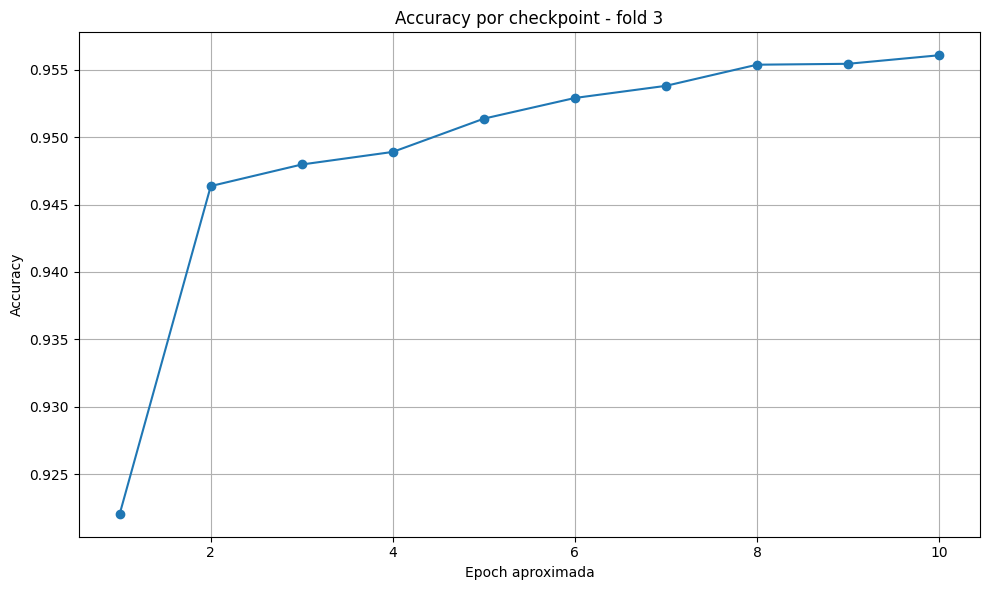

In [11]:
plt.figure(figsize=(10, 6))
plt.plot(df_results["epoch_aprox"], df_results["accuracy"], marker="o")
plt.xlabel("Epoch aproximada")
plt.ylabel("Accuracy")
plt.title(f"Accuracy por checkpoint - fold {k}")
plt.grid(True)
plt.tight_layout()
plt.savefig(ruta_resultados / f"grafica_accuracy_fold_{k}.png", dpi=300)
plt.show()

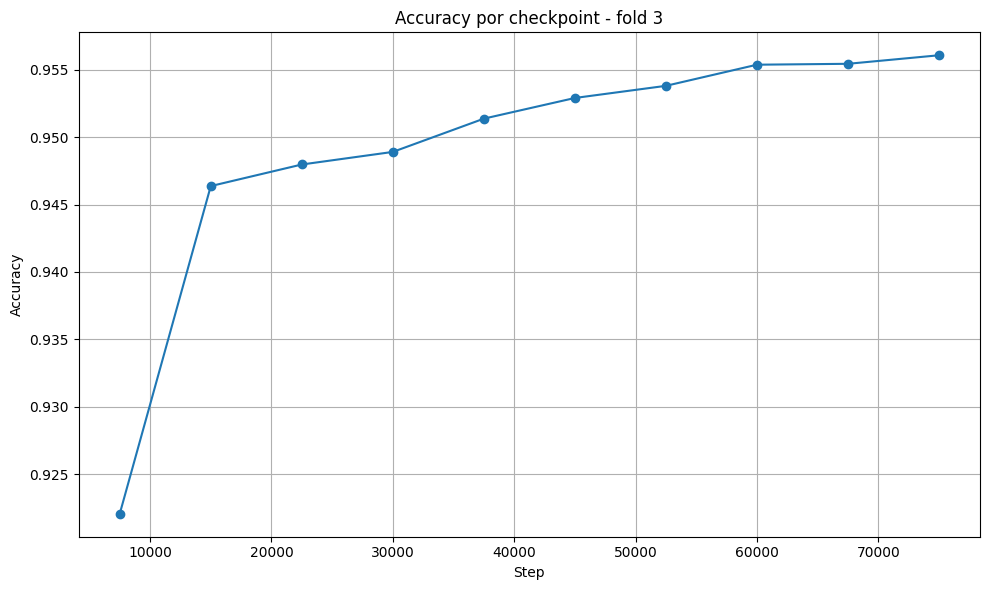

In [12]:
plt.figure(figsize=(10, 6))
plt.plot(df_results["step"], df_results["accuracy"], marker="o")
plt.xlabel("Step")
plt.ylabel("Accuracy")
plt.title(f"Accuracy por checkpoint - fold {k}")
plt.grid(True)
plt.tight_layout()
plt.savefig(ruta_resultados / f"grafica_accuracy_por_step_fold_{k}.png", dpi=300)
plt.show()

In [13]:
trainer_state_path = output_path / "trainer_state.json"
print(trainer_state_path.exists())

if trainer_state_path.exists():
    with open(trainer_state_path, "r", encoding="utf-8") as f:
        trainer_state = json.load(f)

    log_history = trainer_state.get("log_history", [])
    df_logs = pd.DataFrame(log_history)

    df_logs.to_csv(ruta_resultados / f"trainer_log_history_fold_{k}.csv", index=False)

    print(df_logs.head())
    print(df_logs.columns.tolist())

False


In [14]:
if trainer_state_path.exists():
    train_loss_df = df_logs[df_logs["loss"].notna()][["step", "epoch", "loss"]].copy()
    eval_df_logs = df_logs[df_logs["eval_loss"].notna()][["step", "epoch", "eval_loss"]].copy()

    print(train_loss_df.head())
    print(eval_df_logs.head())

In [15]:
if trainer_state_path.exists():
    plt.figure(figsize=(10, 6))

    if not train_loss_df.empty:
        plt.plot(train_loss_df["epoch"], train_loss_df["loss"], marker="o", label="Train loss")

    if not eval_df_logs.empty:
        plt.plot(eval_df_logs["epoch"], eval_df_logs["eval_loss"], marker="s", label="Eval loss")

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"Train loss vs Eval loss - fold {k}")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(ruta_resultados / f"grafica_loss_fold_{k}.png", dpi=300)
    plt.show()

In [16]:
if trainer_state_path.exists() and "eval_accuracy" in df_logs.columns:
    eval_acc_logs = df_logs[df_logs["eval_accuracy"].notna()][["step", "epoch", "eval_accuracy"]].copy()

    df_compare = df_results.merge(
        eval_acc_logs,
        on="step",
        how="left"
    )

    df_compare.to_csv(ruta_resultados / f"comparacion_accuracy_fold_{k}.csv", index=False)
    print(df_compare)

In [17]:
model_final = SimpleT5Wrapper()
model_final.from_pretrained("t5", output_path, use_gpu=use_gpu)

inicio = time.time()

preds_final = model_final.predict(
    val_texts,
    batch_size=batch_size_pred,
    source_max_token_len=source_max_token_len,
    target_max_token_len=target_max_token_len
)

fin = time.time()

accuracy_final = np.mean([p == y for p, y in zip(preds_final, val_labels)])

print("\n=== MODELO FINAL EN RAÍZ ===")
print("Accuracy:", accuracy_final)
print("Tiempo (min):", (fin - inicio) / 60)

Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

Both `max_new_tokens` (=3) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Both `max_new_tokens` (=3) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Both `max_new_tokens` (=3) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Both `max_new_tokens` (=3) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


...

Both `max_new_tokens` (=3) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Both `max_new_tokens` (=3) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Both `max_new_tokens` (=3) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Both `max_new_tokens` (=3) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



=== MODELO FINAL EN RAÍZ ===
Accuracy: 0.9560666666666666
Tiempo (min): 3.2778894503911338


In [18]:
df_modelo_final = pd.DataFrame([{
    "modelo": "output_path_root",
    "accuracy": accuracy_final,
    "tiempo_min": (fin - inicio) / 60
}])

df_modelo_final.to_csv(ruta_resultados / f"modelo_final_fold_{k}.csv", index=False)